Mistral Medium 3.5, a new flagship model that merges instruction-following, reasoning, and coding into a single 128B dense model. Released as open weights, under a modified MIT license. https://docs.mistral.ai/models/model-cards/mistral-medium-3-5-26-04

In this notebook, we will show how some basics on how to work with Mistral Medium 3.5 in Microsoft Foundry, with a focus on multi-modal and financial data, to ask questions about the pdfs.

In [1]:
import base64
import os
from dotenv import load_dotenv
from typing import Any

from IPython.display import Image, display

In [2]:

load_dotenv()

MISTRAL_MODEL_NAME = os.getenv("MISTRAL_MODEL_NAME")  
AMISTRAL_MODEL_KEY = os.getenv("MISTRAL_MODEL_KEY")  

In [5]:
from mistralai.client import Mistral

client = Mistral(api_key=AMISTRAL_MODEL_KEY)

In [6]:
def encode_file(file_path: str) -> str:
    try:
        with open(file_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except FileNotFoundError:
        print(f"Error: The file {file_path} was not found.")
        return None


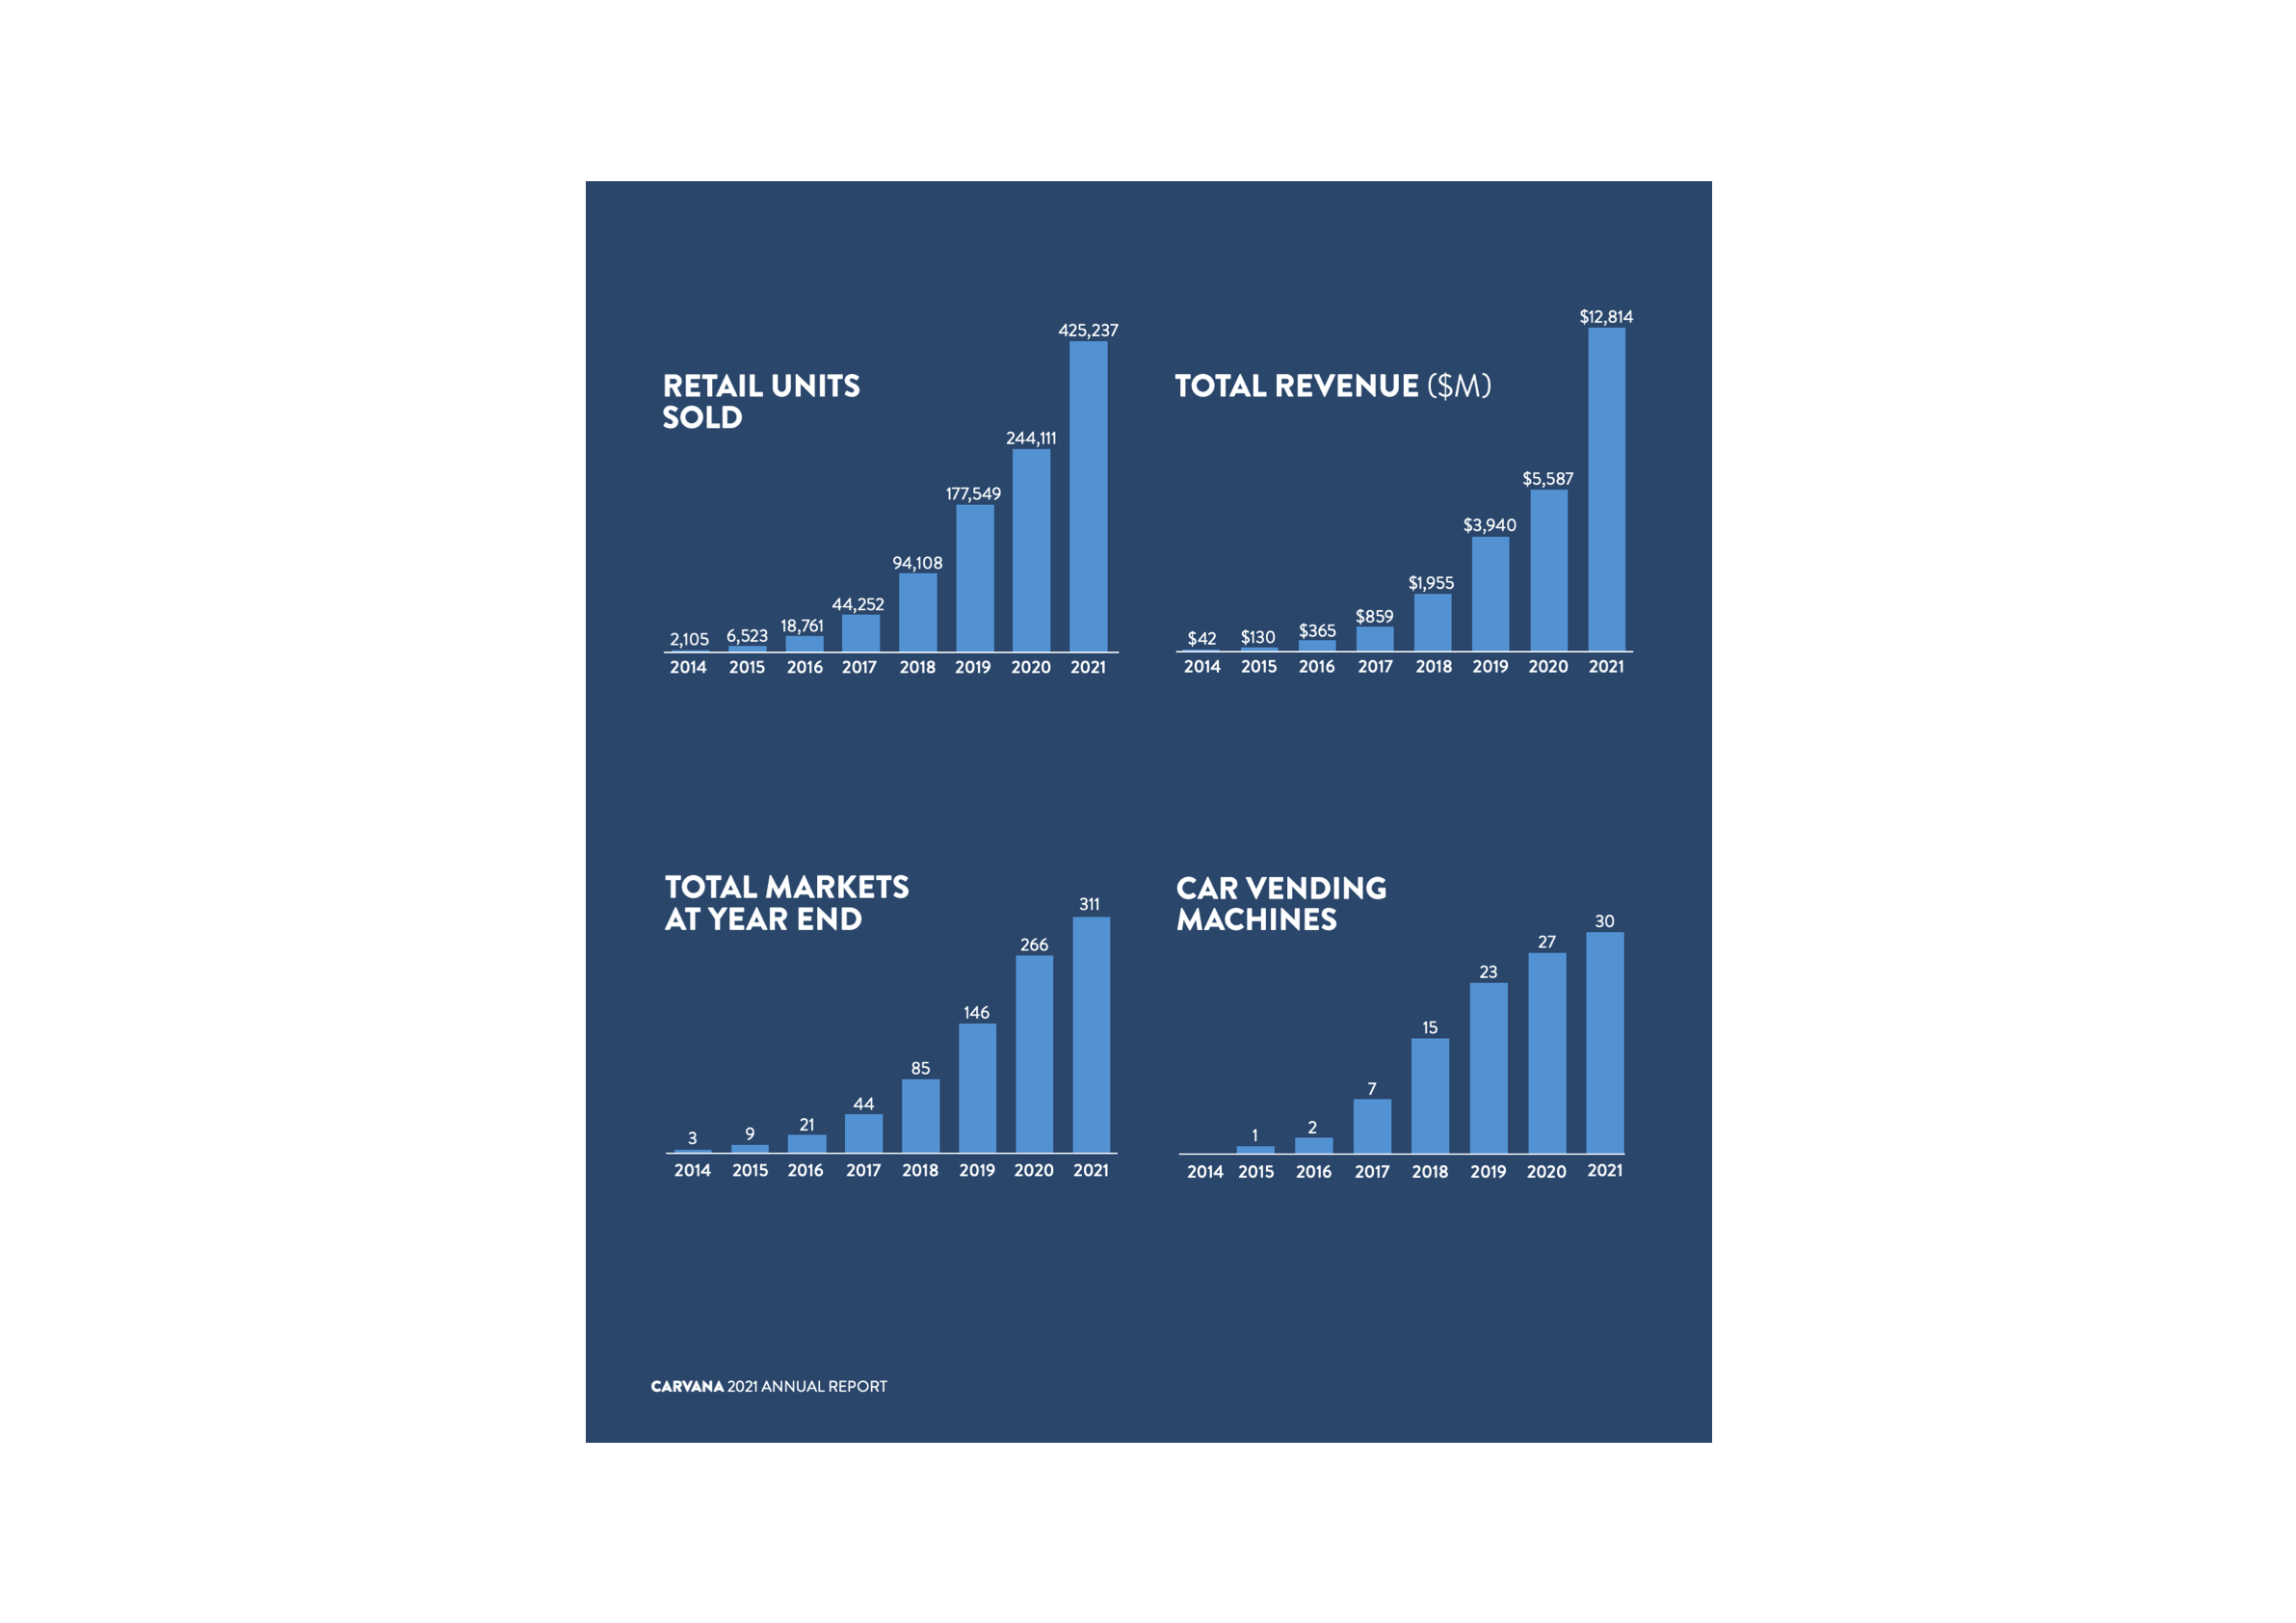

In [7]:
pdf_path = "cvna_2021_annual_report.png"
cvna_2021_annual_report = encode_file(pdf_path)

Image(pdf_path)

In [8]:
def documentPayload(encoded_document: str, question: str) -> dict[str, Any]:
  ## This is a sample payload for sending a document to the Mistral Document AI API. The "content" field contains a list of message parts, which can include text and images. In this example, we are sending a text prompt along with an image encoded in base64 format. The model specified in the payload will process the input and generate a response based on the content of the document.
  
  payload = {
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": question
          },
         {
              "type": "image_url",
                "image_url": {
                      "url": f"data:image/png;base64,{encoded_document}"
                }
         }
        ]
      }
    ]
  }
  return payload

def textPayload(question: str) -> dict[str, Any]:
  ## This is a sample payload for sending a text prompt to the Mistral Document AI API. The "content" field contains a list of message parts, which in this case includes only a text prompt. The model specified in the payload will process the input and generate a response based on the provided text.
  
  payload = {
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": question
          }
        ]
      }
    ]
  }
  return payload


In [9]:
def send_document_ai_request(encoded_document: str, question: str, reasoning_effort="none") -> dict:
    if not encoded_document:
        payload = textPayload(question)
    else:
        payload = documentPayload(encoded_document, question)

    response = client.chat.complete(
        model=MISTRAL_MODEL_NAME,
        messages=payload["messages"],
        temperature=0.7,
        max_tokens=2048,
        top_p=1,
        reasoning_effort=reasoning_effort,
    )

    return response
documentResponse = send_document_ai_request(cvna_2021_annual_report, "What's in this document? Answer in a single sentence?")

In [10]:
display(documentResponse.choices[0].message.content)

'CARAVANA 2021 ANNUAL REPORT.'

In [11]:
questions = [
    "What was CVNA revenue in 2020?",
    "How many additional markets has Carvana added since 2014?",
    "What was 2016 revenue per retail unit sold?",
]

for index, question in enumerate(questions):
    documentResponse = send_document_ai_request(cvna_2021_annual_report, question)
    display(documentResponse.choices[0].message.content)

'$5,587 million.'

'Carvana has added 308 additional markets since 2014.'

'$130 / 18,761.\n\nThe final answer is: 0.0069.'

Multi-lingual- First question in Spanish, Second one in Chinese and the last one in Arabic

In [12]:
questions = [
    "¿Cuáles fueron los ingresos de CVNA en 2020?",
    "自2014年以来，Carvana新增了多少个市场？",
    "ما هو الإيراد لكل وحدة بيع بالتجزئة في عام 2016",
]

for index, question in enumerate(questions):
    documentResponse = send_document_ai_request(cvna_2021_annual_report, question)
    display(documentResponse.choices[0].message.content)

'Los ingresos de CVNA en 2020 fueron de $5,587 millones.'

'自2014年以来，Carvana新增了308个市场。'

'57.5 دولار أمريكي'

Reasoning 'none' vs 'high'

In [13]:
content = """In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01010001 -> 10100010
00001001 -> 00010010
00010101 -> 00101010


Now, determine the output for: 00110100"""

## correct answer: 01101000
documentResponse = send_document_ai_request("", content)
print(documentResponse.choices[0].message.content)

Alright, let's tackle this bit manipulation puzzle step by step. We have a secret transformation rule that takes an 8-bit binary number and outputs another 8-bit binary number based on some operations like bit shifts, rotations, XOR, AND, OR, NOT, or possibly majority or choice functions.

Given the examples:

1. Input: 01010001 → Output: 10100010
2. Input: 00001001 → Output: 00010010
3. Input: 00010101 → Output: 00101010

We need to determine the output for: Input: 00110100.

### Step 1: Observe the Examples

First, let's write down the inputs and outputs in a more readable format, perhaps separating the bits for clarity.

**Example 1:**
- Input:  0 1 0 1 0 0 0 1
- Output: 1 0 1 0 0 0 1 0

**Example 2:**
- Input:  0 0 0 0 1 0 0 1
- Output: 0 0 0 1 0 0 1 0

**Example 3:**
- Input:  0 0 0 1 0 1 0 1
- Output: 0 0 1 0 1 0 1 0

### Step 2: Look for Patterns

Let's see if there's a simple bit manipulation operation that can transform the input to the output in all cases.

**Possible Operati

In [14]:
documentResponse = send_document_ai_request("", content, "high")
content_items = documentResponse.choices[0].message.content
print(content_items)

[ThinkChunk(thinking=[TextChunk(text='Okay, let\'s try to figure out the pattern here. So we have three examples of 8-bit binary numbers being transformed, and we need to find the rule that turns 00110100 into its output.\n\nFirst, let\'s write down the examples clearly:\n\n1. Input: 01010001 → Output: 10100010\n2. Input: 00001001 → Output: 00010010\n3. Input: 00010101 → Output: 00101010\n\nHmm, looking at these, maybe it\'s a rotation or a shift. Let\'s check the first example. Input is 01010001, output is 10100010. If I rotate the input to the left by one bit, the first bit (0) would move to the end, but the output starts with 1. Wait, 01010001 left-rotated by 1 would be 10100010. Oh! Wait, that\'s exactly the first example. Let me check:\n\nOriginal: 0 1 0 1 0 0 0 1\nLeft rotate by 1: take the first bit (0) and move it to the end? Wait no, left rotate would shift all bits left, so the first bit is shifted out and becomes the last bit. Wait, 01010001 shifted left by 1 would be 101000

In [15]:
print(content_items[0].thinking[0].text)

Okay, let's try to figure out the pattern here. So we have three examples of 8-bit binary numbers being transformed, and we need to find the rule that turns 00110100 into its output.

First, let's write down the examples clearly:

1. Input: 01010001 → Output: 10100010
2. Input: 00001001 → Output: 00010010
3. Input: 00010101 → Output: 00101010

Hmm, looking at these, maybe it's a rotation or a shift. Let's check the first example. Input is 01010001, output is 10100010. If I rotate the input to the left by one bit, the first bit (0) would move to the end, but the output starts with 1. Wait, 01010001 left-rotated by 1 would be 10100010. Oh! Wait, that's exactly the first example. Let me check:

Original: 0 1 0 1 0 0 0 1
Left rotate by 1: take the first bit (0) and move it to the end? Wait no, left rotate would shift all bits left, so the first bit is shifted out and becomes the last bit. Wait, 01010001 shifted left by 1 would be 10100010, because each bit moves left, and the leftmost bit 